# Crawling & Analisis Data Polutan Udara di Kabupaten Gresik

**Nama:** Ahmad Syahrul Farihin

**NIM:** 240411100031

**Mata Kuliah:** Pengantar Sains Data (PSD)

## Latar Belakang

Kabupaten Gresik dikenal sebagai salah satu wilayah industri yang cukup besar di Jawa Timur. Di daerah ini terdapat berbagai kegiatan industri, seperti produksi semen, pupuk dan petrokimia, pengolahan logam, pengolahan minyak nabati, hingga aktivitas di kawasan pelabuhan dan kawasan industri terpadu JIIPE. Selain kegiatan industri, Gresik juga dilewati jalur Pantai Utara (Pantura) Jawa yang menjadi salah satu jalur transportasi dengan aktivitas kendaraan yang cukup padat.

Berbagai aktivitas tersebut dapat memberikan dampak terhadap kondisi udara di wilayah Gresik karena berpotensi menghasilkan beberapa jenis polutan. Polutan yang dapat ditemukan antara lain Karbon Monoksida (CO), Nitrogen Dioksida (NO2), Formaldehida (HCHO), Ozon troposferik (O3), Sulfur Dioksida (SO2), dan Metana (CH4). Karena itu, pengumpulan dan pemantauan data mengenai keenam polutan tersebut diperlukan untuk melihat bagaimana kondisi kualitas udara di Kabupaten Gresik serta mengetahui perubahan konsentrasinya dari waktu ke waktu.


## 1. Business Understanding

### a. Tujuan

Tugas ini dilakukan untuk mengetahui sumber yang berpotensi menghasilkan polutan serta melihat kondisi kualitas udara di Kabupaten Gresik. Analisis dilakukan dengan mengambil data satelit untuk enam jenis polutan, yaitu CO, NO2, HCHO, O3, SO2, dan CH4. Data yang diperoleh kemudian digunakan untuk melakukan eksplorasi data (*data understanding*) dan membuat visualisasi dalam bentuk *time series* dengan periode pengamatan minimal satu tahun sebelum 31 Agustus 2026.

### b. Manfaat

Beberapa manfaat yang diharapkan dari pelaksanaan tugas ini adalah:

1. Mengetahui gambaran pola serta perubahan konsentrasi setiap polutan di wilayah Kabupaten Gresik dari waktu ke waktu.

2. Membantu melihat kemungkinan sumber utama dari masing-masing polutan dengan mempertimbangkan karakteristik wilayah, seperti kawasan industri, jalur transportasi, pertanian, dan aktivitas lainnya.

3. Memberikan gambaran awal mengenai kondisi kualitas udara di Kabupaten Gresik yang dapat digunakan sebagai bahan evaluasi.

4. Menyediakan dasar data untuk dilakukan analisis lebih lanjut, seperti *preprocessing* dan pemodelan pada tahap berikutnya.

5. Meningkatkan pemahaman dan kemampuan dalam mengambil data lingkungan dari sumber satelit (*remote sensing*), serta melakukan proses *data understanding* pada data berbentuk *time series*.

### c. Kemungkinan Sumber Masing-Masing Polutan

| Polutan                     | Deskripsi Singkat                                                                                                    | Kemungkinan Sumber                                                                                                                                                    |
| --------------------------- | -------------------------------------------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **CO (Karbon Monoksida)**   | Gas yang umumnya terbentuk akibat proses pembakaran bahan bakar yang tidak berlangsung sempurna.                     | Kendaraan bermotor, pembakaran biomassa atau lahan, kegiatan industri yang menggunakan proses pembakaran, serta kebakaran hutan dan lahan.                            |
| **NO2 (Nitrogen Dioksida)** | Gas pencemar yang dapat terbentuk dari proses pembakaran pada suhu tinggi.                                           | Kendaraan bermotor, pembangkit listrik, kegiatan industri seperti pabrik semen dan petrokimia, serta pembakaran bahan bakar fosil.                                    |
| **HCHO (Formaldehida)**     | Salah satu senyawa organik volatil (VOC) yang dapat terbentuk melalui proses oksidasi hidrokarbon di atmosfer.       | Industri kimia dan petrokimia, kebakaran hutan dan lahan, emisi kendaraan, serta proses oksidasi VOC yang berasal dari vegetasi.                                      |
| **O3 (Ozon Troposferik)**   | Polutan sekunder yang terbentuk melalui reaksi kimia di atmosfer dan tidak langsung dilepaskan oleh sumber tertentu. | Reaksi fotokimia antara NOx dan senyawa organik volatil (VOC) dengan bantuan sinar matahari, terutama di wilayah dengan aktivitas kendaraan dan industri yang tinggi. |
| **SO2 (Sulfur Dioksida)**   | Gas yang dihasilkan dari pembakaran bahan bakar yang memiliki kandungan sulfur.                                      | Pembangkit listrik tenaga uap atau batu bara, industri semen, peleburan logam, serta penggunaan bahan bakar minyak dan batu bara dalam kegiatan industri.             |
| **CH4 (Metana)**            | Salah satu gas rumah kaca yang juga termasuk dalam kelompok senyawa yang dapat ditemukan di atmosfer.                | Lahan persawahan, tempat pembuangan akhir (TPA) sampah, peternakan, kebocoran pada distribusi gas alam, serta kegiatan industri migas.                                |

### d. Deskripsi Data

Data yang digunakan dalam tugas ini berasal dari citra satelit Sentinel-5P TROPOMI (*Tropospheric Monitoring Instrument*). Satelit tersebut merupakan bagian dari program Copernicus dan dikelola oleh European Space Agency (ESA). Data diperoleh melalui platform Copernicus Data Space Ecosystem dengan memanfaatkan pustaka `openeo` pada Python dan koleksi data `SENTINEL_5P_L2`.

Setiap band yang digunakan, yaitu CO, NO2, HCHO, O3, SO2, dan CH4, menunjukkan informasi mengenai kandungan gas di atmosfer. Sebagian besar data polutan dinyatakan sebagai total column density dengan satuan mol/m². Resolusi spasialnya berada pada kisaran 5,5 × 3,5 km hingga 7 × 7 km, tergantung pada jenis produk yang digunakan. Data tersedia secara harian, meskipun pada hari tertentu dapat terdapat data yang kosong karena faktor seperti tutupan awan.

**Catatan mengenai satuan:** data untuk CO, NO2, HCHO, O3, dan SO2 menggunakan satuan kolom vertikal mol/m². Sementara itu, data CH4 menggunakan satuan ppb (parts per billion) dalam bentuk *dry-air column-averaged mixing ratio*, bukan mol/m². Perbedaan satuan tersebut membuat nilai CH4 berada pada kisaran ribuan, yaitu sekitar 1800–1900, sedangkan polutan lainnya memiliki nilai dengan skala yang jauh lebih kecil. Oleh karena itu, nilai CH4 tidak dapat dibandingkan secara langsung dengan polutan lainnya tanpa melakukan penyesuaian skala atau satuan terlebih dahulu.

Dalam proses pengambilan data menggunakan openEO/Sentinel Hub API, satu perintah `load_collection` pada implementasi yang digunakan hanya dapat mengambil satu band atau jenis polutan dari koleksi Sentinel-5P L2. Karena itu, pengambilan data untuk keenam polutan dilakukan secara terpisah dengan menggunakan proses *loop*. Setiap hasil pengambilan kemudian disimpan dan diunduh dalam bentuk file NetCDF (`.nc`) sesuai dengan masing-masing jenis polutan.


## 2. Penentuan Wilayah Kajian (Area of Interest) Menggunakan GeoJSON.io

Wilayah kajian ditentukan menggunakan berkas **GeoJSON** berbentuk polygon yang mencakup wilayah Kabupaten Gresik (dan sekitarnya), digambar melalui [geojson.io](https://geojson.io) kemudian disimpan sebagai berkas `.geojson` dan dibaca kembali menggunakan Python untuk membatasi wilayah pengambilan data pada tahap crawling.

In [1]:
import json

# GeoJSON wilayah kajian (Kabupaten Gresik dan sekitarnya), digambar melalui geojson.io
aoi_geojson = {
    "type": "FeatureCollection",
    "features": [
        {
            "type": "Feature",
            "properties": {},
            "geometry": {
                "type": "Polygon",
                "coordinates": [
                    [
                        [112.55788600733189, -7.1497735],
                        [112.6117995, -7.1232868],
                        [112.6562032, -7.1497735],
                        [112.6675169, -7.1838502],
                        [112.6562032, -7.218131475385974],
                        [112.605102, -7.2404483],
                        [112.55788600733189, -7.218131475385974],
                        [112.55788600733189, -7.1497735]
                    ]
                ]
            }
        }
    ]
}

with open("aoi_gresik.geojson", "w") as f:
    json.dump(aoi_geojson, f, indent=2)

print("Berkas aoi_gresik.geojson berhasil disimpan.")

Berkas aoi_gresik.geojson berhasil disimpan.


In [2]:
with open("aoi_gresik.geojson", "r") as f:
    aoi_geojson = json.load(f)

polygon_coords = aoi_geojson["features"][0]["geometry"]["coordinates"][0]
lons = [c[0] for c in polygon_coords]
lats = [c[1] for c in polygon_coords]

bbox = {
    "west": min(lons),
    "south": min(lats),
    "east": max(lons),
    "north": max(lats)
}

print("Bounding box wilayah kajian (Gresik):")
print(bbox)

Bounding box wilayah kajian (Gresik):
{'west': 112.55788600733189, 'south': -7.2404483, 'east': 112.6675169, 'north': -7.1232868}


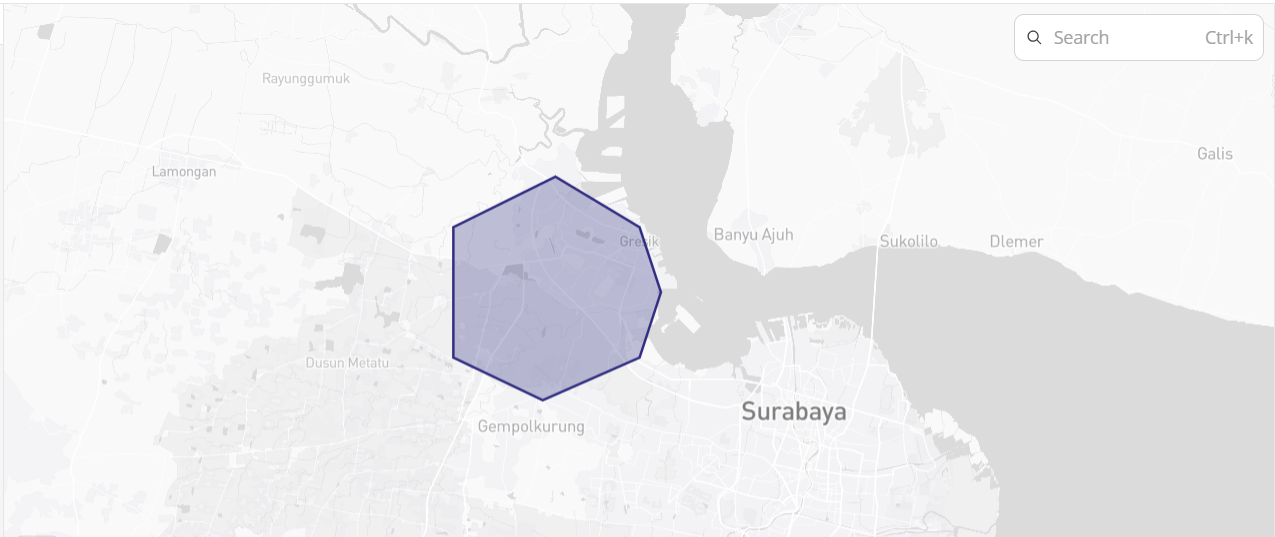

## 3. Data Collection (Crawling Data)

### a. Instalasi Library dan Koneksi ke Copernicus Data Space Ecosystem

In [3]:
pip install openeo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.2/349.2 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 8.8 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


In [4]:
import openeo
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=CNWK-JFSS 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.


### b. Crawling Enam Polutan (CO, NO2, HCHO, O3, SO2, CH4)

Rentang waktu pengamatan ditentukan minimal satu tahun hingga tanggal 31 Agustus 2026, sesuai ketentuan tugas. Karena satu permintaan hanya dapat memuat satu band, proses crawling dilakukan melalui perulangan (`loop`) untuk setiap polutan, dan masing-masing hasil diunduh sebagai berkas NetCDF terpisah.

In [6]:
import pandas as pd

pollutants = ["CO", "NO2", "HCHO", "O3", "SO2", "CH4"]

start_date = "2025-08-31"
end_date = "2026-08-30"

for pol in pollutants:
    cube = connection.load_collection(
        "SENTINEL_5P_L2",
        temporal_extent=[start_date, end_date],
        spatial_extent=bbox,
        bands=[pol],
    )
    cube_daily = cube.aggregate_temporal_period(reducer="mean", period="day")
    cube_daily.execute_batch(title=f"{pol} in Gresik", outputfile=f"{pol}_Gresik.nc")
    print(f"Selesai mengunduh data {pol} -> {pol}_Gresik.nc")

# Ringkasan rentang tanggal hasil crawling
date_range = pd.date_range(start=start_date, end=end_date, freq="D")

print("\nData berhasil disimpan!")
print(f"Tanggal pertama: {date_range[0].strftime('%Y-%m-%d')}")
print(f"Tanggal terakhir: {date_range[-1].strftime('%Y-%m-%d')}")
print(f"Jumlah baris: {len(date_range)}")

0:00:00 Job 'j-260830133116465bb8ca98bd664c495f': send 'start'
0:00:01 Job 'j-260830133116465bb8ca98bd664c495f': created (progress 0%)
0:00:07 Job 'j-260830133116465bb8ca98bd664c495f': queued (progress 0%)
0:00:13 Job 'j-260830133116465bb8ca98bd664c495f': queued (progress 0%)
0:00:21 Job 'j-260830133116465bb8ca98bd664c495f': queued (progress 0%)
0:00:31 Job 'j-260830133116465bb8ca98bd664c495f': queued (progress 0%)
0:00:43 Job 'j-260830133116465bb8ca98bd664c495f': queued (progress 0%)
0:00:58 Job 'j-260830133116465bb8ca98bd664c495f': running (progress N/A)
0:01:18 Job 'j-260830133116465bb8ca98bd664c495f': running (progress N/A)
0:01:42 Job 'j-260830133116465bb8ca98bd664c495f': running (progress N/A)
0:02:12 Job 'j-260830133116465bb8ca98bd664c495f': running (progress N/A)
0:02:49 Job 'j-260830133116465bb8ca98bd664c495f': running (progress N/A)
0:03:36 Job 'j-260830133116465bb8ca98bd664c495f': running (progress N/A)
0:04:34 Job 'j-260830133116465bb8ca98bd664c495f': finished (progress 100

## 4. Data Understanding

### a. Membaca Seluruh Berkas NetCDF dan Menyimpan ke CSV

Setiap berkas NetCDF hasil crawling dibaca, dihitung rata-rata nilai per hari untuk seluruh grid dalam wilayah kajian, kemudian disimpan ke dalam berkas CSV terpisah untuk masing-masing polutan.

In [7]:
!pip install netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 90.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 66.8 MB/s eta 0:00:00


In [8]:
import netCDF4
import numpy as np

def read_daily_mean(band_name, filename):
    ds = netCDF4.Dataset(filename)

    values = ds.variables[band_name][:]
    time = ds.variables["t"][:]
    time_units = ds.variables["t"].units

    dates = netCDF4.num2date(
        time,
        units=time_units
    )

    daily_dates = [
        d.strftime("%Y-%m-%d")
        for d in dates
    ]

    daily_mean = []

    for i in range(len(values)):

        # Ambil satu hari
        data_harian = values[i]

        # Hitung mean dengan mengabaikan masked value
        mean_value = np.ma.mean(data_harian)

        # Ubah masked menjadi NaN
        if np.ma.is_masked(mean_value):
            mean_value = np.nan
        else:
            mean_value = float(mean_value)

        daily_mean.append(mean_value)

    df = pd.DataFrame({
        "date": daily_dates,
        band_name: daily_mean
    })

    df["date"] = pd.to_datetime(df["date"])

    # Pastikan benar-benar numeric
    df[band_name] = pd.to_numeric(
        df[band_name],
        errors="coerce"
    )

    return df

# Membaca semua data polutan
dataframes = {}

for pol in pollutants:
    df_pol = read_daily_mean(
        pol,
        f"{pol}_Gresik.nc"
    )

    dataframes[pol] = df_pol

    print(
        f"{pol}: {df_pol.shape[0]} baris data berhasil dibaca"
    )


# ==========================================
# GABUNGKAN LANGSUNG BERDASARKAN TANGGAL
# ==========================================

merged_df = dataframes[pollutants[0]][["date"]].copy()

for pol in pollutants:
    merged_df = merged_df.merge(
        dataframes[pol][["date", pol]],
        on="date",
        how="outer"
    )

# Urutkan berdasarkan tanggal
merged_df = merged_df.sort_values(
    "date"
).reset_index(drop=True)


# ==========================================
# SIMPAN HANYA SATU CSV
# ==========================================

merged_df.to_csv(
    "all_polutan_Gresik_timeseries.csv",
    index=False
)

print("\nData berhasil disimpan!")
print("Nama file: all_polutan_Gresik_timeseries.csv")
print("Jumlah baris:", len(merged_df))
print("Kolom:", merged_df.columns.tolist())

display(merged_df.head())

CO: 364 baris data berhasil dibaca
NO2: 362 baris data berhasil dibaca
HCHO: 360 baris data berhasil dibaca
O3: 360 baris data berhasil dibaca
SO2: 360 baris data berhasil dibaca
CH4: 215 baris data berhasil dibaca

Data berhasil disimpan!
Nama file: all_polutan_Gresik_timeseries.csv
Jumlah baris: 364
Kolom: ['date', 'CO', 'NO2', 'HCHO', 'O3', 'SO2', 'CH4']


,date,CO,NO2,HCHO,O3,SO2,CH4
0,2025-08-31,0.027154,0.000029,0.000006,0.116457,0.000175,NaN
1,2025-09-01,0.023740,0.000041,0.000095,0.115472,-0.000057,NaN
2,2025-09-02,0.025013,0.000029,0.000052,0.114820,0.000119,1864.20105
3,2025-09-03,0.024046,0.000052,0.000112,0.113629,0.000010,NaN
4,2025-09-04,0.028691,0.000053,0.000169,0.113531,0.000274,NaN


### b. Mengecek Struktur dan Isi Data

Untuk masing-masing polutan, diperiksa struktur data (tipe kolom, jumlah baris) serta beberapa baris pertama untuk memastikan hasil crawling sesuai yang diharapkan.

In [9]:
print("=== Struktur Data Polutan Gresik ===")
merged_df.info()

print("\n=== Ukuran Dataset ===")
print("Jumlah baris :", merged_df.shape[0])
print("Jumlah kolom :", merged_df.shape[1])

print("\n=== Nama Kolom ===")
print(merged_df.columns.tolist())

print("\n=== 5 Data Pertama ===")
display(merged_df.head())

print("\n=== 5 Data Terakhir ===")
display(merged_df.tail())

=== Struktur Data Polutan Gresik ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 364 entries, 0 to 363
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    364 non-null    datetime64[ns]
 1   CO      267 non-null    float64       
 2   NO2     237 non-null    float64       
 3   HCHO    297 non-null    float64       
 4   O3      360 non-null    float64       
 5   SO2     281 non-null    float64       
 6   CH4     50 non-null     float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 20.0 KB

=== Ukuran Dataset ===
Jumlah baris : 364
Jumlah kolom : 7

=== Nama Kolom ===
['date', 'CO', 'NO2', 'HCHO', 'O3', 'SO2', 'CH4']

=== 5 Data Pertama ===


,date,CO,NO2,HCHO,O3,SO2,CH4
0,2025-08-31,0.027154,0.000029,0.000006,0.116457,0.000175,NaN
1,2025-09-01,0.023740,0.000041,0.000095,0.115472,-0.000057,NaN
2,2025-09-02,0.025013,0.000029,0.000052,0.114820,0.000119,1864.20105
3,2025-09-03,0.024046,0.000052,0.000112,0.113629,0.000010,NaN
4,2025-09-04,0.028691,0.000053,0.000169,0.113531,0.000274,NaN



=== 5 Data Terakhir ===


,date,CO,NO2,HCHO,O3,SO2,CH4
359,2026-08-25,0.029289,0.000044,0.000085,0.121385,-0.000130,1891.427368
360,2026-08-26,0.028848,0.000054,0.000025,0.119590,0.000225,1896.860718
361,2026-08-27,0.032734,0.000093,0.000162,0.117796,0.000037,1912.785319
362,2026-08-28,0.036582,0.000071,0.000192,0.117713,0.000047,1875.684082
363,2026-08-29,0.035085,0.000060,0.000150,0.115774,0.000060,NaN


### c. Mengecek Missing Value

Missing value pada data Sentinel-5P umumnya terjadi akibat tutupan awan (*cloud cover*) yang menghalangi pengukuran satelit, sehingga sensor tidak mencatat nilai valid pada tanggal tertentu.

In [10]:
print(f"{'Polutan':<8}{'Jumlah Baris':<15}{'Missing Value':<15}{'Persentase':<10}")

for pol in pollutants:
    n_total = len(merged_df)
    n_missing = merged_df[pol].isna().sum()
    pct = n_missing / n_total * 100 if n_total > 0 else 0
    print(f"{pol:<8}{n_total:<15}{n_missing:<15}{pct:.2f}%")

Polutan Jumlah Baris   Missing Value  Persentase
CO      364            97             26.65%
NO2     364            127            34.89%
HCHO    364            67             18.41%
O3      364            4              1.10%
SO2     364            83             22.80%
CH4     364            314            86.26%


Persentase *missing value* pada setiap polutan tidak sama. Dari hasil pengolahan data, **CH4 memiliki jumlah *missing value* paling tinggi, yaitu sekitar 86.26%**. Kondisi ini tidak berarti proses *crawling* mengalami kegagalan. Tingginya *missing value* pada CH4 berkaitan dengan proses pengambilan datanya dari Sentinel-5P yang menggunakan kanal SWIR (*Short-Wave Infrared*).

Kanal tersebut membutuhkan kondisi langit yang sangat cerah agar pengukuran dapat menghasilkan data yang valid. Selain itu, pengukuran CH4 hanya dapat dilakukan pada area yang berada di atas permukaan daratan. Persyaratan tersebut lebih ketat dibandingkan kanal UV-VIS yang digunakan untuk mengukur CO, NO2, HCHO, O3, dan SO2. Akibatnya, jumlah data CH4 yang berhasil diperoleh dan dinyatakan valid lebih sedikit dibandingkan dengan data polutan lainnya.


### d. Mengecek Data Aneh / Outlier

Statistik deskriptif dan deteksi outlier menggunakan metode *Interquartile Range* (IQR) digunakan untuk mengidentifikasi nilai yang berada jauh di luar sebaran normal data, termasuk mengecek kewajaran nilai (apakah terdapat nilai negatif ekstrem yang tidak wajar secara fisis).

In [11]:
summary_rows = []

for pol in pollutants:

    # Ambil kolom polutan dari dataset utama
    series = merged_df[pol].dropna()

    # Kuartil
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)

    # IQR
    IQR = Q3 - Q1

    # Batas outlier
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Jumlah outlier
    n_outliers = (
        (series < lower_bound) |
        (series > upper_bound)
    ).sum()

    summary_rows.append({
        "Polutan": pol,
        "Min": series.min(),
        "Max": series.max(),
        "Mean": series.mean(),
        "Std": series.std(),
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Batas Bawah": lower_bound,
        "Batas Atas": upper_bound,
        "Jumlah Outlier IQR": n_outliers
    })

summary_df = pd.DataFrame(summary_rows)

display(summary_df)

,Polutan,Min,Max,Mean,Std,Q1,Q3,IQR,Batas Bawah,Batas Atas,Jumlah Outlier IQR
0,CO,0.021569,0.042343,0.029208,0.003299,0.027079,0.030997,0.003918,0.021202,0.036875,6
1,NO2,0.000009,0.000229,0.000065,0.000034,0.000046,0.000074,0.000028,0.000004,0.000116,20
2,HCHO,-0.000011,0.000522,0.000175,0.000080,0.000124,0.000216,0.000092,-0.000015,0.000355,6
3,O3,0.110616,0.122855,0.115901,0.002365,0.114152,0.117340,0.003188,0.109371,0.122122,1
4,SO2,-0.000364,0.000951,0.000101,0.000180,-0.000008,0.000192,0.000199,-0.000307,0.000491,12
5,CH4,1781.022705,1927.624878,1890.962658,23.392568,1881.886383,1904.976807,23.090424,1847.250748,1939.612442,2


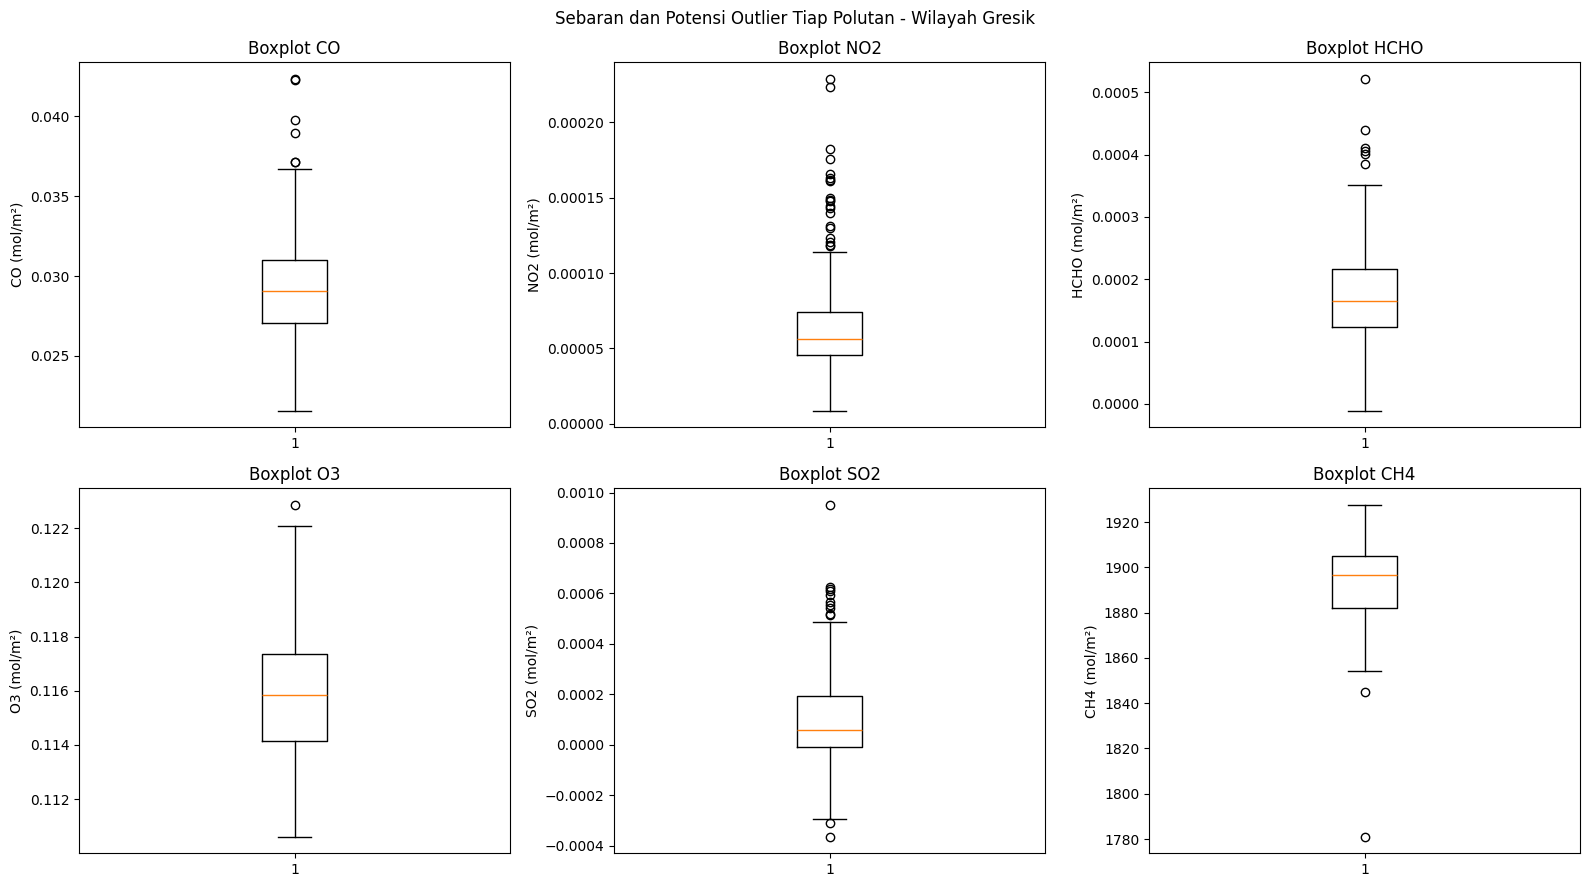

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, pol in zip(axes.flatten(), pollutants):
    ax.boxplot(
        merged_df[pol].dropna()
    )
    ax.set_title(f"Boxplot {pol}")
    ax.set_ylabel(f"{pol} (mol/m²)")

plt.suptitle(
    "Sebaran dan Potensi Outlier Tiap Polutan - Wilayah Gresik"
)

plt.tight_layout()
plt.show()

Beberapa nilai SO₂ dan HCHO tercatat sedikit negatif, seperti SO₂ dengan nilai minimum sekitar -0,000364 mol/m². Nilai tersebut bukan menunjukkan konsentrasi gas yang benar-benar negatif, tetapi dapat disebabkan oleh *noise* pada proses *retrieval* satelit ketika konsentrasi gas sangat rendah. Nilai ini perlu diperhatikan pada tahap *preprocessing* dan tidak langsung dihapus.

Boxplot CH₄ memiliki skala yang berbeda karena satuannya menggunakan ppb, sedangkan polutan lainnya menggunakan mol/m². Oleh karena itu, nilai CH₄ tidak dapat dibandingkan langsung dengan polutan lain dalam grafik yang sama.


## 5. Visualisasi Time Series

Grafik berikut menampilkan perubahan konsentrasi masing-masing polutan di wilayah Kabupaten Gresik dari waktu ke waktu, menggunakan data harian hasil crawling (tanpa tahap pembersihan lebih lanjut, sesuai lingkup tugas ini yang berhenti pada tahap Data Understanding).

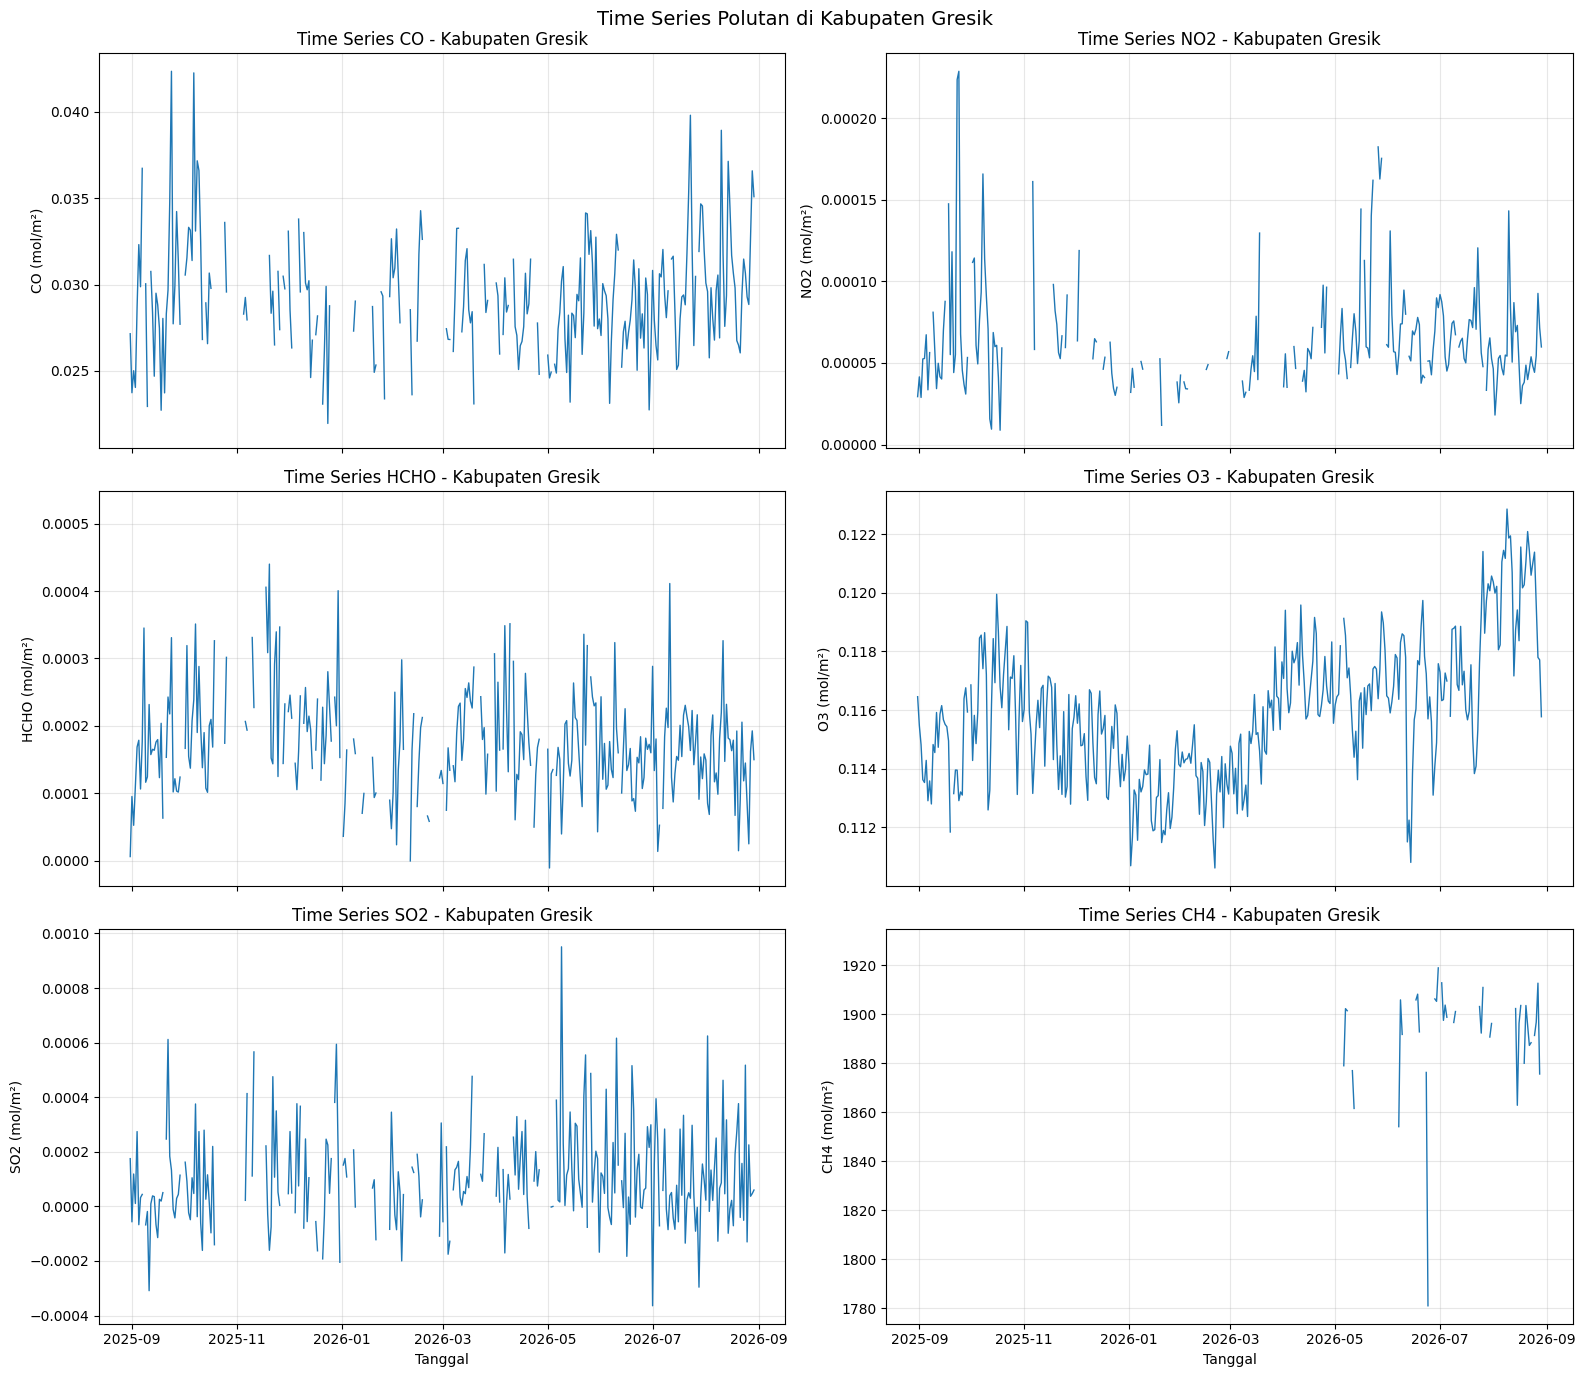

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    3, 2,
    figsize=(16, 14),
    sharex=True
)

for ax, pol in zip(axes.flatten(), pollutants):
    ax.plot(
        merged_df["date"],
        merged_df[pol],
        linewidth=1
    )
    ax.set_title(
        f"Time Series {pol} - Kabupaten Gresik"
    )
    ax.set_ylabel(
        f"{pol} (mol/m²)"
    )
    ax.grid(alpha=0.3)

axes[-1, 0].set_xlabel("Tanggal")
axes[-1, 1].set_xlabel("Tanggal")

plt.suptitle(
    "Time Series Polutan di Kabupaten Gresik",
    fontsize=14
)

plt.tight_layout()
plt.show()

## Kesimpulan

Berdasarkan proses yang telah dilakukan, data enam jenis polutan udara, yaitu CO, NO₂, HCHO, O₃, SO₂, dan CH₄ di Kabupaten Gresik berhasil dikumpulkan melalui proses *crawling* data Sentinel-5P menggunakan OpenEO dengan batas wilayah yang ditentukan melalui GeoJSON. Seluruh data yang diperoleh kemudian digabungkan dan disimpan dalam satu file CSV.

Pada tahap *data understanding*, dilakukan pemeriksaan terhadap struktur data, jumlah *missing value*, serta identifikasi *outlier* menggunakan metode IQR. Selain itu, data juga divisualisasikan dalam bentuk *time series* untuk melihat perubahan konsentrasi polutan dari waktu ke waktu. Hasil analisis menunjukkan bahwa konsentrasi polutan mengalami perubahan dan fluktuasi selama periode pengamatan. Perubahan tersebut kemungkinan dipengaruhi oleh berbagai faktor, seperti aktivitas industri, transportasi, dan kondisi meteorologis. Data dan hasil analisis awal ini selanjutnya dapat digunakan sebagai dasar untuk melakukan tahap *preprocessing* dan pemodelan pada proses berikutnya.
